# CanopyLab field trials — a tour in Positron

**This project contains synthetic data and analysis created for demonstration purposes only.**
CanopyLab Agronomics is a fictional crop science company; every station, hybrid and
protection programme below was generated for this demo.

This is an ordinary Jupyter notebook (`.ipynb`), opened in Positron's notebook editor.
If you came from VS Code, nothing here should surprise you: the same file format, the
same cell-by-cell execution, the same keyboard shortcuts. What Positron adds is the
data-science furniture around it.

**Four things to look at while this runs**

| Pane | What to notice |
|---|---|
| **Variables** | Every dataframe in the kernel, with its shape. Click one to open it. |
| **Data Explorer** | A sortable, filterable grid with a column summary — not a `print()`. |
| **Plots** | Every figure, with history, so you can flip back to the previous version. |
| **Connections** | The DuckDB file browsable as a database, before you write any code. |

The notebook is also a deployable artifact: `rsconnect deploy notebook` publishes it to
Posit Connect, where it can be re-executed on a schedule and emailed to a distribution
list. Same file, no rewrite.

## 1. The data

One row per harvested plot: five hybrids × three protection programmes × four
replicates, at six stations, over five seasons.

In [1]:
import polars as pl
import duckdb
from pathlib import Path

DATA = Path("../data")
if not (DATA / "synthetic-field-trials.csv").exists():
    raise SystemExit("Run `uv run python data/generate_data.py` first.")

trials = pl.read_csv(DATA / "synthetic-field-trials.csv")
sites = pl.read_csv(DATA / "synthetic-sites.csv")

print(f"{trials.height:,} plots, {trials.width} columns")
trials.head(5)

1,800 plots, 14 columns


plot_id,season,site_id,site_name,region,variety,treatment,replicate,rainfall_mm,growing_degree_days,disease_pressure_index,stand_count_per_m2,lodging_pct,yield_t_ha
str,i64,str,str,str,str,str,i64,f64,f64,f64,f64,f64,f64
"""P00001""",2021,"""S01""","""North Ridge Station""","""Northern Plains""","""CL-Aurora 21""","""Untreated Check""",1,510.0,2445.0,55.7,7.15,4.1,9.06
"""P00002""",2021,"""S01""","""North Ridge Station""","""Northern Plains""","""CL-Aurora 21""","""Untreated Check""",2,510.0,2445.0,42.7,8.51,3.0,9.6
"""P00003""",2021,"""S01""","""North Ridge Station""","""Northern Plains""","""CL-Aurora 21""","""Untreated Check""",3,510.0,2445.0,55.3,8.33,4.3,10.14
"""P00004""",2021,"""S01""","""North Ridge Station""","""Northern Plains""","""CL-Aurora 21""","""Untreated Check""",4,510.0,2445.0,55.8,8.51,8.3,8.19
"""P00005""",2021,"""S01""","""North Ridge Station""","""Northern Plains""","""CL-Aurora 21""","""Programme Alpha""",1,510.0,2445.0,22.3,7.51,3.8,10.8


> **Try it now:** open the **Variables** pane, find `trials`, and click it. The Data
> Explorer opens on 1,800 rows: sort by `yield_t_ha`, filter `treatment` to
> `Untreated Check`, and read the column summaries down the left. That is the first
> ten minutes of any analysis, and none of it needed a line of code.

## 2. Where the yield goes

A plot's yield is the hybrid's genetic potential, minus what disease and drought took
back. Because the protection programmes suppress disease, they should show up as a
yield gain — largest for the hybrids with the least disease tolerance of their own.

In [2]:
summary = (
    trials.group_by("treatment")
    .agg(
        plots=pl.len(),
        mean_yield=pl.col("yield_t_ha").mean().round(2),
        mean_disease=pl.col("disease_pressure_index").mean().round(1),
    )
    .sort("mean_yield")
)
summary

treatment,plots,mean_yield,mean_disease
str,u32,f64,f64
"""Untreated Check""",600,9.67,47.5
"""Programme Alpha""",600,10.16,21.4
"""Programme Bravo""",600,10.36,9.5


In [3]:
from great_tables import GT, md as gt_md

gain = (
    trials.pivot(on="treatment", index="variety", values="yield_t_ha", aggregate_function="mean")
    .with_columns(
        gain_bravo=(pl.col("Programme Bravo") - pl.col("Untreated Check")).round(2),
        gain_alpha=(pl.col("Programme Alpha") - pl.col("Untreated Check")).round(2),
    )
    .select("variety", "Untreated Check", "Programme Alpha", "Programme Bravo", "gain_alpha", "gain_bravo")
    .with_columns(pl.col("Untreated Check", "Programme Alpha", "Programme Bravo").round(2))
    .sort("gain_bravo", descending=True)
)

(
    GT(gain)
    .tab_header(
        title="Yield response to each protection programme",
        subtitle="Mean tonnes per hectare across all stations and seasons, and the gain over the untreated check",
    )
    .cols_label(variety="Hybrid", gain_alpha="Gain: Alpha", gain_bravo="Gain: Bravo")
    .tab_source_note(gt_md("*Synthetic data, generated for demonstration purposes only.*"))
)

GT(_tbl_data=shape: (5, 6)
┌──────────────┬─────────────────┬─────────────────┬─────────────────┬────────────┬────────────┐
│ variety      ┆ Untreated Check ┆ Programme Alpha ┆ Programme Bravo ┆ gain_alpha ┆ gain_bravo │
│ ---          ┆ ---             ┆ ---             ┆ ---             ┆ ---        ┆ ---        │
│ str          ┆ f64             ┆ f64             ┆ f64             ┆ f64        ┆ f64        │
╞══════════════╪═════════════════╪═════════════════╪═════════════════╪════════════╪════════════╡
│ CL-Ember 33  ┆ 10.11           ┆ 10.78           ┆ 11.11           ┆ 0.67       ┆ 1.0        │
│ CL-Aurora 21 ┆ 9.19            ┆ 9.77            ┆ 9.97            ┆ 0.58       ┆ 0.79       │
│ CL-Delta 12  ┆ 9.81            ┆ 10.34           ┆ 10.47           ┆ 0.53       ┆ 0.66       │
│ CL-Cinder 07 ┆ 8.76            ┆ 9.22            ┆ 9.38            ┆ 0.46       ┆ 0.62       │
│ CL-Beacon 44 ┆ 10.5            ┆ 10.68           ┆ 10.87           ┆ 0.18       ┆ 0.37       │
└──────────────┴─────────────────┴─────────────────┴─────────────────┴────────────┴────────────┘, _body=<great_tables._gt_data.Body object at 0x11e387cb0>, _boxhead=Boxhead([ColInfo(var='variety', type=<ColInfoTypeEnum.default: 1>, column_label='Hybrid', column_align='left', column_width=None), ColInfo(var='Untreated Check', type=<ColInfoTypeEnum.default: 1>, column_label='Untreated Check', column_align='right', column_width=None), ColInfo(var='Programme Alpha', type=<ColInfoTypeEnum.default: 1>, column_label='Programme Alpha', column_align='right', column_width=None), ColInfo(var='Programme Bravo', type=<ColInfoTypeEnum.default: 1>, column_label='Programme Bravo', column_align='right', column_width=None), ColInfo(var='gain_alpha', type=<ColInfoTypeEnum.default: 1>, column_label='Gain: Alpha', column_align='right', column_width=None), ColInfo(var='gain_bravo', type=<ColInfoTypeEnum.default: 1>, column_label='Gain: Bravo', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x11e387770>, _spanners=Spanners([]), _heading=Heading(title='Yield response to each protection programme', subtitle='Mean tonnes per hectare across all stations and seasons, and the gain over the untreated check', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x11e387e00>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x11e55dd10>, _source_notes=[Md(text='*Synthetic data, generated for demonstration purposes only.*')], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x11e5b8050>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True

## 3. SQL, without leaving the notebook

The same DuckDB file that the **Connections** pane browses can be queried from Python.
Nothing is loaded into memory that the query did not ask for — the aggregation happens
in the database.

In [4]:
connection = duckdb.connect(str(DATA / "synthetic-agronomy.duckdb"), read_only=True)

by_site = connection.sql("""
    SELECT
        s.region,
        s.site_name,
        s.soil_type,
        round(avg(t.yield_t_ha), 2)             AS mean_yield_t_ha,
        round(avg(t.disease_pressure_index), 1) AS mean_disease_index
    FROM field_trials t
    JOIN sites s USING (site_id)
    GROUP BY s.region, s.site_name, s.soil_type
    ORDER BY mean_yield_t_ha DESC
""").pl()

by_site

region,site_name,soil_type,mean_yield_t_ha,mean_disease_index
str,str,str,f64,f64
"""Central Valley""","""Lakeview Station""","""Silt loam""",10.94,25.4
"""Central Valley""","""River Bend Station""","""Sandy loam""",10.6,22.6
"""Northern Plains""","""North Ridge Station""","""Silt loam""",10.3,25.5
"""Eastern Belt""","""Sandhill Station""","""Loamy sand""",9.94,21.7
"""Northern Plains""","""Clay Flats Station""","""Heavy clay""",9.42,32.7
"""Eastern Belt""","""High Plains Station""","""Clay loam""",9.18,29.0


## 4. ggsql: the query *is* the chart

[ggsql](https://ggsql.org) extends SQL with the grammar of graphics. The query below
lives in `sql/04-disease-vs-yield.ggsql` — a plain text file that gets code-reviewed
like any other. `VISUALISE` maps columns to aesthetics, `DRAW` picks the mark, `FACET`
splits the panels. The database does the work; the chart comes back as Vega-Lite.

Read the three panels left to right: the programme does not change the *slope* of the
relationship between disease and yield, it moves the plots down the x-axis to where the
slope costs less.

In [5]:
import ggsql
import altair as alt

query = Path("../sql/04-disease-vs-yield.ggsql").read_text()
ggsql.validate(query)  # grammar check, no database round trip

reader = ggsql.DuckDBReader(f"duckdb://{DATA / 'synthetic-agronomy.duckdb'}")
alt.Chart.from_json(ggsql.VegaLiteWriter().render(reader.execute(query)))

alt.FacetChart(...)

## 5. A model small enough to explain

One linear model, on standardized inputs, so the coefficients are directly comparable:
each is the change in yield (t/ha) for a one-standard-deviation move in that input, or —
for the categorical terms — relative to `CL-Aurora 21` on the untreated check.

The point of a demo model is not the score. It is that the whole thing is legible, and
that the artifact it produces is the same artifact you would deploy.

In [6]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

NUMERIC = ["disease_pressure_index", "rainfall_mm", "growing_degree_days", "stand_count_per_m2"]
CATEGORICAL = ["variety", "treatment", "region"]

features = trials.select(NUMERIC + CATEGORICAL).to_pandas()
target = trials.get_column("yield_t_ha").to_numpy()

train_x, test_x, train_y, test_y = train_test_split(features, target, test_size=0.25, random_state=20260831)

model = Pipeline([
    ("prep", ColumnTransformer([
        ("numeric", StandardScaler(), NUMERIC),
        ("nominal", OneHotEncoder(drop="first", sparse_output=False), CATEGORICAL),
    ], verbose_feature_names_out=False)),
    ("fit", LinearRegression()),
]).fit(train_x, train_y)

predicted = model.predict(test_x)
print(f"Held-out R2  {r2_score(test_y, predicted):.3f}")
print(f"Held-out MAE {mean_absolute_error(test_y, predicted):.3f} t/ha")

coefficients = (
    pl.DataFrame({
        "term": model.named_steps["prep"].get_feature_names_out(),
        "effect_t_ha": model.named_steps["fit"].coef_,
    })
    .with_columns(pl.col("effect_t_ha").round(3))
    .sort(pl.col("effect_t_ha").abs(), descending=True)
)
coefficients

Held-out R2  0.775
Held-out MAE 0.414 t/ha


term,effect_t_ha
str,f64
"""variety_CL-Beacon 44""",1.051
"""region_Eastern Belt""",-1.021
"""variety_CL-Ember 33""",1.02
"""variety_CL-Delta 12""",0.582
"""variety_CL-Cinder 07""",-0.524
…,…
"""disease_pressure_index""",-0.372
"""growing_degree_days""",-0.124
"""treatment_Programme Bravo""",-0.026


## 6. One chart, brand colours from `_brand.yml`

The same file that themes the Quarto report and the Shiny app supplies the palette here,
so a re-brand for a different customer is a one-file edit rather than a search for hex
codes.

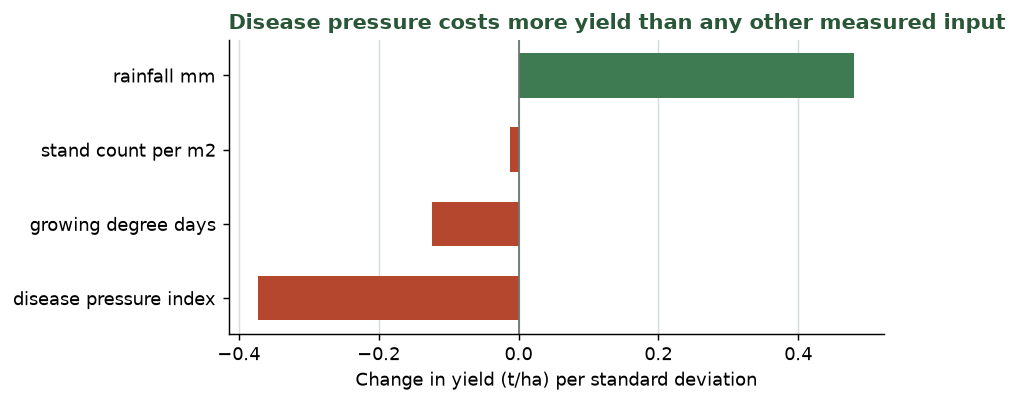

In [7]:
import matplotlib.pyplot as plt
import yaml

palette = yaml.safe_load(Path("../_brand.yml").read_text())["color"]["palette"]
plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": palette["hairline"], "axes.axisbelow": True})

ordered = coefficients.filter(pl.col("term").is_in(NUMERIC)).sort("effect_t_ha")

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.barh(
    [t.replace("_", " ") for t in ordered.get_column("term")],
    ordered.get_column("effect_t_ha"),
    color=[palette["clay"] if v < 0 else palette["leaf"] for v in ordered.get_column("effect_t_ha")],
    height=0.6,
)
ax.axvline(0, color=palette["stone"], linewidth=1)
ax.grid(axis="y", visible=False)
ax.set_xlabel("Change in yield (t/ha) per standard deviation")
ax.set_title("Disease pressure costs more yield than any other measured input",
             loc="left", color=palette["canopy"], fontsize=11.5, fontweight="bold")
fig.tight_layout()

## 7. Getting this off the laptop

Everything in this notebook runs the same way on Posit Workbench, which is the point: the
image that runs your development session is the image that runs the deployed content, so
"works on my machine" stops being a category of bug.

From here:

```bash
# Publish this notebook to Connect (rendered, re-executable, schedulable)
rsconnect deploy notebook notebooks/field-trial-tour.ipynb -n canopylab

# Or let CI do it: .github/workflows/deploy-connect.yml publishes on merge to main
```

The R half of this project — an internal package, a Quarto report and a Shiny app — sits
in the same repository and deploys the same way. See `posit-README.md` for the full tour
and `MCP-SETUP.md` to point Posit Assistant at this project's MCP server on Connect.

---

*This project contains synthetic data and analysis created for demonstration purposes only.*